<a href="https://colab.research.google.com/github/yamunar0504-cloud/Country-Development-Segmentation-ML/blob/main/Unsupervised_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Country Development Segmentation Using K-Means Clustering -Unsupervised Learning**

***Understamding The Dataset***

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/Country-data.csv')
print(df)

                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2       5.82    553  
1         4.49   

***Explaining each Feature***

1.child_mort(child mortality)-Number of children under 5 who die per 1000 births(who died under 5 years old)

- Indicates healthcare quality & living condition
- High - Poor health system
- Low - Better health system

2.exports - Percentage of goods and services  exported compared to gdp
- Higher - Strong international trade

3.health - Percentage of total gdp spent on healthcare
- High - Country invests more in healthcare

4.import - Percentage of goods and services imported relative to gdp
- High - Country depends more on external goods

5.income - Average income per person in the country(USD)
- High -Wealtheir country (developed country)

6.inflation - Rate at which prices increase anually.(annual growth rate of total gdp)
- High inflation - Economic instability

7.life_expec(life expectancy)- Average life expectancy of people in the country
(average no.of years a person in expected to live in specific country)
- High - better living conditions

8.total_fer(total fertility)- Average number of children per woman(It measures population growth)
- High -Often seen in developing countries

9.gdp(gross domestic product gdp)- Gdp per capita(economic output per person)
- High - Strong economy (developed country)



- ***country - Name of the country [It not considered as feature because it a text format, so it does not represent a measurable variable]***



In [ ]:
X=df[['child_mort','exports',	'health','imports','income','inflation','life_expec','total_fer','gdpp']]

***Identifing Features***

Economic Indicators:

1.income

2.gdpp

3.exports

4.imports

5.inflation

Health Indicators:

1.child_mort

2.health

3.life_expec

Social indicators:

1.total_fer

***Data Quality & Preprocessing***

In [ ]:
df.head(20)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [ ]:
df.tail(20)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
147,Tanzania,71.9,18.7,6.01,29.1,2090,9.25,59.3,5.43,702
148,Thailand,14.9,66.5,3.88,60.8,13500,4.08,76.6,1.55,5080
149,Timor-Leste,62.6,2.2,9.12,27.8,1850,26.50,71.1,6.23,3600
150,Togo,90.3,40.2,7.65,57.3,1210,1.18,58.7,4.87,488
151,Tonga,17.4,12.4,5.07,60.3,4980,3.68,69.9,3.91,3550
152,Tunisia,17.4,50.5,6.21,55.3,10400,3.82,76.9,2.14,4140
153,Turkey,19.1,20.4,6.74,25.5,18000,7.01,78.2,2.15,10700
154,Turkmenistan,62.0,76.3,2.50,44.5,9940,2.31,67.9,2.83,4440
155,Uganda,81.0,17.1,9.01,28.6,1540,10.60,56.8,6.15,595
156,Ukraine,11.7,47.1,7.72,51.1,7820,13.40,70.4,1.44,2970


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.shape

(167, 10)

In [ ]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [ ]:
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000



- Child mortality varies widely (min ≈ 2.6, max ≈ 208). High values indicate underdeveloped countries, while low values indicate developed countries with better healthcare.

- Exports range from very low to very high (≈ 0.1 to 200). Higher export percentages usually indicate stronger economies and global trade participation.

- Health spending varies across countries (≈ 1.8 to 17.9). Higher health expenditure suggests better healthcare systems and development.

- Imports vary significantly (≈ 0.06 to 174), showing differences in trade dependency among countries.

- Income shows large variation (≈ 609 to 125,000 USD), indicating major economic differences between underdeveloped and developed countries.

- Inflation ranges from negative values to very high values, showing economic instability in some countries.

- Life expectancy ranges from ≈ 32 to 82 years. Higher life expectancy is typically associated with developed countries.

- Total fertility rate ranges from ≈ 1.15 to 7.49. Higher fertility is often seen in underdeveloped countries, while lower fertility is common in developed countries.

- GDP per capita ranges from ≈ 231 to 105,000 USD, showing large economic gaps and helping differentiate country development levels.



In [ ]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
df.duplicated().sum()

np.int64(0)

***Identifing columns that require scaling***


Columns that require scaling:
- child_mort
- income
- gdpp
- life_expec
- exports
- imports
- inflation
- total_fer
- health

Because their ranges are very different.


***Explaining why feature scaling is critical for clustering in this dataset***

*K-Means clustering uses distance calculations.
If features have different scales, large values (income, GDP) dominate the clustering process.*

*Feature scaling is necessary because clustering algorithms rely on distance calculations. Since variables such as income and GDP have much larger ranges compared to life expectancy or fertility rate, scaling ensures that all variables contribute equally to the clustering process.*

***Exploratory Data Analysis (EDA)***

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**HISTOGRAM PLOTS**

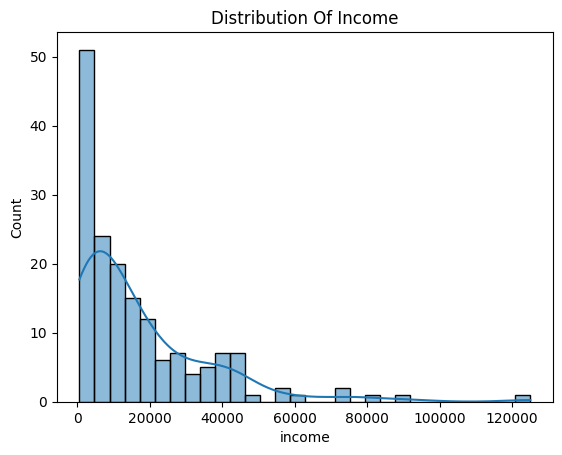

In [ ]:
sns.histplot(x=df['income'],bins=30,kde=True)
plt.title('Distribution Of Income')
plt.show()

**NOTE** - The income distribution is right-skewed,it means most countries have low to moderate income, while only a few have very high income. This indicates economic inequality  across  countries,where only few countries have  strong economic conditions. This variation helps distinguish underdeveloped, developing, and developed countries in the clustering analysis.

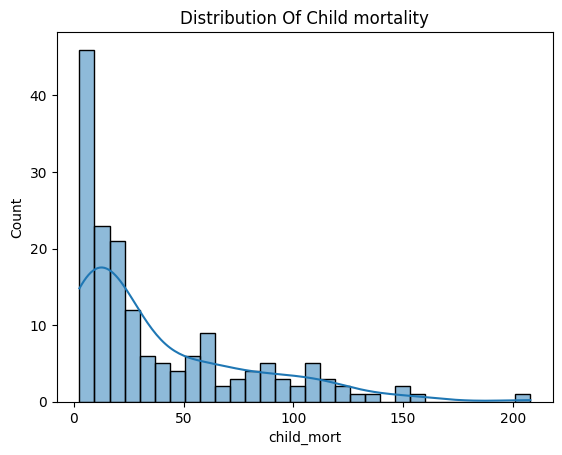

In [ ]:
sns.histplot(x=df['child_mort'],bins=30,kde=True)
plt.title('Distribution Of Child mortality')
plt.show()

**NOTE** -The child mortality distribution shows right-skewed, indicating many countries have moderate to low child mortality rates, while some countries have extremely high mortality rates. High child mortality is often associated with poor healthcare infrastructure and lower development levels.

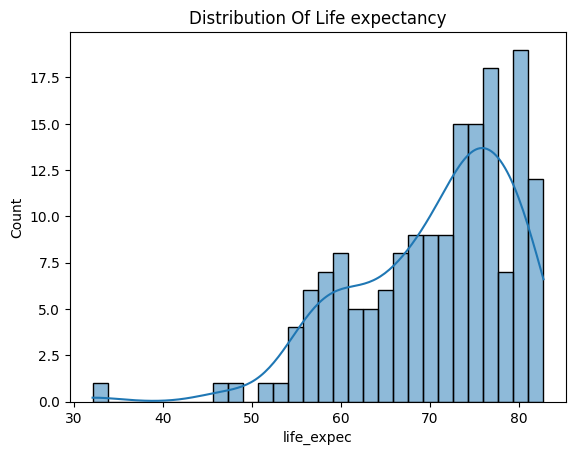

In [ ]:
sns.histplot(x=df['life_expec'],bins=30,kde=True)
plt.title('Distribution Of Life expectancy')
plt.show()

**NOTE**-The life expectancy distribution shows that most countries have life expectancy between 65 and 80 years, indicating better health conditions in many nations. A few countries have lower life expectancy, which is commonly associated with underdeveloped regions. This indicator helps differentiate countries based on health and development levels in the clustering analysis.

**Countries With Extreme Values**

In [ ]:
df.sort_values('income',ascending=False)[['country','income']].head(20)

,country,income
123,Qatar,125000
91,Luxembourg,91700
23,Brunei,80600
82,Kuwait,75200
133,Singapore,72100
114,Norway,62300
157,United Arab Emirates,57600
145,Switzerland,55500
159,United States,49400
73,Ireland,45700


In [ ]:
df.sort_values('child_mort',ascending =False)[['country','child_mort']].head(20)

,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0
113,Nigeria,130.0
112,Niger,123.0
3,Angola,119.0
25,Burkina Faso,116.0
37,"Congo, Dem. Rep.",116.0


In [ ]:
df.sort_values('life_expec')[['country','life_expec']].head(20)

,country,life_expec
66,Haiti,32.1
87,Lesotho,46.5
31,Central African Republic,47.5
166,Zambia,52.0
94,Malawi,53.1
137,South Africa,54.3
106,Mozambique,54.5
132,Sierra Leone,55.0
64,Guinea-Bissau,55.6
0,Afghanistan,56.2


***NOTE*** - **Countries with extremely low income, high child mortality, and low life expectancy represent the most vulnerable nations. These countries typically suffer from poor healthcare systems, economic instability, and limited access to basic services.**

**Insights distinguishing underdeveloped, developing, and developed countries.**

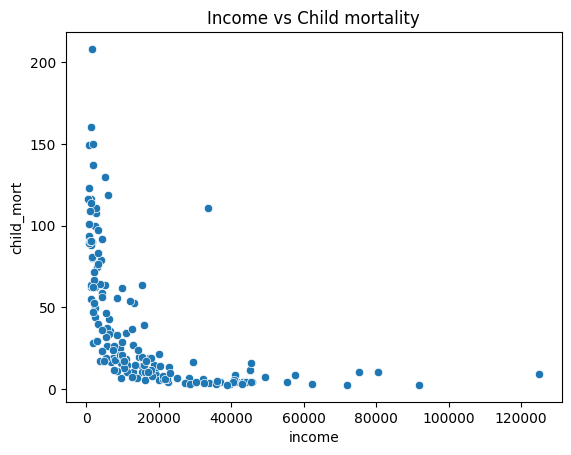

In [ ]:
sns.scatterplot(x='income',y='child_mort',data=df)
plt.title('Income vs Child mortality')
plt.show()

# low income,High Child mortality - Under developed

**NOTE**-The scatter plot shows a negative relationship between income and child mortality. Countries with low income tend to have high child mortality, indicating underdeveloped conditions.

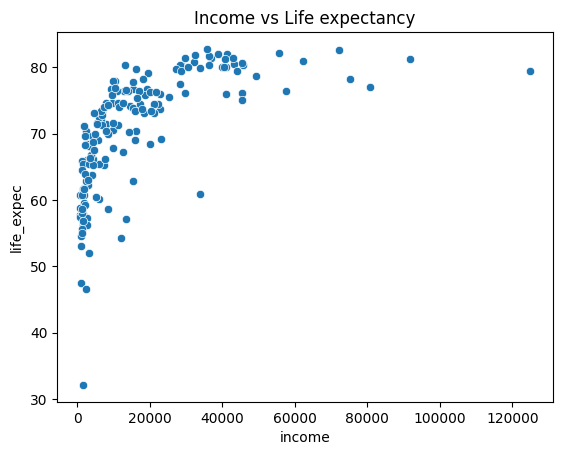

In [ ]:
sns.scatterplot(x='income',y='life_expec',data=df)
plt.title('Income vs Life expectancy')
plt.show()

**NOTE** -The scatter plot shows a positive relationship between income and life expectancy. Countries with higher income tend to have higher life expectancy, indicating better healthcare and living conditions.

***Exploratory Data Analysis shows that income distribution is highly skewed, with only a few countries having very high income. Child mortality varies significantly across countries, indicating differences in healthcare infrastructure. Life expectancy is higher in economically developed nations and lower in underdeveloped regions. Countries with low income, high child mortality, and low life expectancy are likely to be underdeveloped, while countries with high income and long life expectancy represent developed economies.***

***Feature Selection For Clustering***

**The selected features include child mortality, exports, health spending, imports, income, inflation, life expectancy, fertility rate, and GDP per capita. These variables represent economic conditions, healthcare quality, and social development of countries. The country column was excluded because it is a categorical identifier and does not contribute to clustering. Using these indicators allows the clustering algorithm to group countries based on their development level, which aligns with the NGO’s objective of prioritizing funding for countries that need the most support.**

***Clustering Algorithm***

***K-Means Clustering***

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X=df[['child_mort','exports',	'health','imports','income','inflation','life_expec','total_fer','gdpp']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

model=KMeans(n_clusters=3,random_state=42)
df['cluster']=model.fit_predict(X_scaled)

centroids=model.cluster_centers_
print('centroids:',centroids)
print('Inertia:',model.inertia_)
print('silhouette_score:',silhouette_score(X_scaled,df['cluster']))
print(df)
df.head(20)

centroids: [[-0.39328196 -0.03058375 -0.20617903  0.01956247 -0.25093021 -0.00578315
   0.22676244 -0.40257862 -0.35583225]
 [-0.82744866  0.64507985  0.72741122  0.19063895  1.48424268 -0.48492064
   1.07957853 -0.79187687  1.61599536]
 [ 1.41356446 -0.45761494 -0.18789794 -0.18989721 -0.70783863  0.39898875
  -1.29703104  1.40287396 -0.61276131]]
Inertia: 831.5351582151586
silhouette_score: 0.285600988953231
                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    29

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,0
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,0
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,0
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,1
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,1
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,0


**NOTE**-*K-Means clustering grouped the countries into 3 clusters based on development indicators. The inertia value (831.53) indicates cluster compactness (lower is better). The silhouette score (0.285) shows moderate clustering quality, meaning the clusters are reasonably separated into underdeveloped, developing, and developed countries.*

***Hierarchical Clustering***

In [ ]:
import pandas as pd
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.metrics import silhouette_score

X=df[['child_mort','exports',	'health','imports','income','inflation','life_expec','total_fer','gdpp']]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

model=AgglomerativeClustering(n_clusters=3)
df['cluster']=model.fit_predict(X_scaled)

print('silhouette_score:',silhouette_score(X_scaled,df['cluster']))
print(df)
df.head(60)


silhouette_score: 0.24563001303300652
                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  cluster  
0         9.44   

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,Albania,16.6,28.00,6.55,48.6,9930,4.490,76.3,1.65,4090,1
2,Algeria,27.3,38.40,4.17,31.4,12900,16.100,76.5,2.89,4460,1
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.50,6.03,58.9,19100,1.440,76.8,2.13,12200,1
5,Argentina,14.5,18.90,8.10,16.0,18700,20.900,75.8,2.37,10300,1
6,Armenia,18.1,20.80,4.40,45.3,6700,7.770,73.3,1.69,3220,1
7,Australia,4.8,19.80,8.73,20.9,41400,1.160,82.0,1.93,51900,0
8,Austria,4.3,51.30,11.00,47.8,43200,0.873,80.5,1.44,46900,0
9,Azerbaijan,39.2,54.30,5.88,20.7,16000,13.800,69.1,1.92,5840,1


**NOTE** -*Hierarchical (Agglomerative) clustering was applied to group countries based on socio-economic and health indicators. The silhouette score obtained is 0.245, which indicates moderate cluster separation but slightly weaker compared to K-Means (0.285). Therefore, K-Means provides better clustering performance for this dataset, though hierarchical clustering still helps visualize relationships between countries based on development indicators.*

***Both K-Means and Hierarchical clustering were applied to group countries based on socio-economic indicators. The silhouette score for  K-Means (0.285) is higher than that of Hierarchical clustering (0.245), indicating better cluster separation and grouping quality. Therefore, K-Means performs better for this dataset, as it forms more compact and well-separated clusters for identifying underdeveloped, developing, and developed countries.***

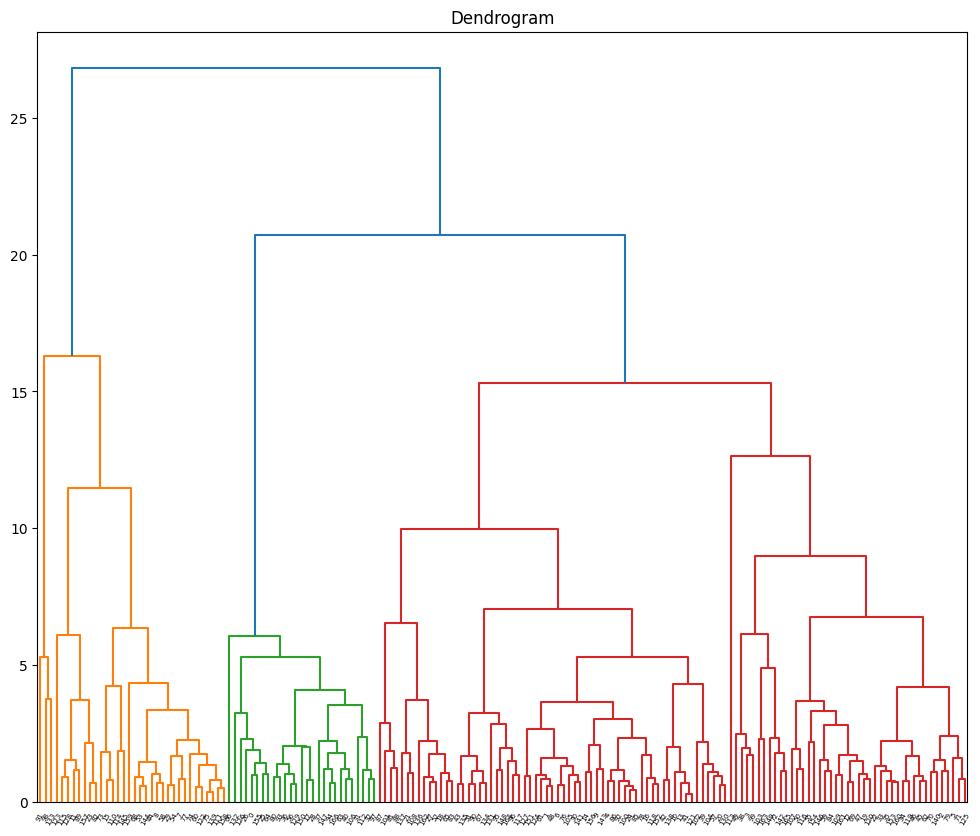

In [ ]:
### ???
from scipy.cluster.hierarchy import dendrogram,linkage
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
linked=linkage(X_scaled,method='ward')
dendrogram(linked)
plt.xticks(rotation=60)
plt.title('Dendrogram')
plt.show()

**Optimal Number Of Clusters**

***Elbow Method to determine the optimal number of clusters***

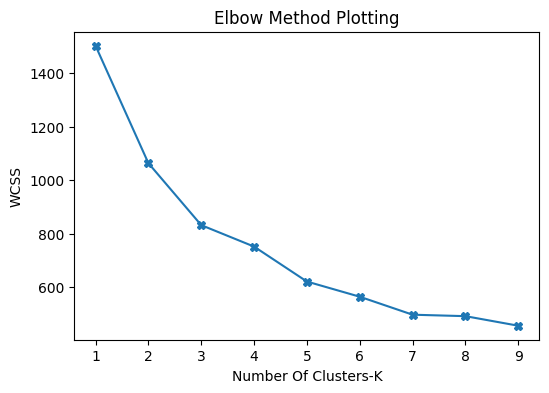

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


X=df[['child_mort','exports',	'health','imports','income','inflation','life_expec','total_fer','gdpp']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#Elbow Method
wcss=[]                       #it store the wcss value for each cluster number
for i in range(1,10):         # different cluster numbers k=1,k=2

  model_kmeans=KMeans(n_clusters=i,random_state=42, n_init='auto') #n_init='auto'- run k-means multiple timeswith different centriods and choose best clustering automatically
  model_kmeans.fit(X_scaled)
  wcss.append(model_kmeans.inertia_)

#Elbow Plotting
plt.figure(figsize=(6,4))
plt.plot(range(1,10),wcss,marker='X')
plt.xlabel('Number Of Clusters-K')
plt.ylabel('WCSS')
plt.title('Elbow Method Plotting')
plt.show()


***Silhouette Score***

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


X=df[['child_mort','exports',	'health','imports','income','inflation','life_expec','total_fer','gdpp']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#Silhouette Score

for k in range(2,10):
  model.kmeans=KMeans(n_clusters=k,random_state=42)
  labels=model.fit_predict(X_scaled)
  print('clusters:',k,'silhouette_score:',silhouette_score(X_scaled,labels))

clusters: 2 silhouette_score: 0.24563001303300652
clusters: 3 silhouette_score: 0.24563001303300652
clusters: 4 silhouette_score: 0.24563001303300652
clusters: 5 silhouette_score: 0.24563001303300652
clusters: 6 silhouette_score: 0.24563001303300652
clusters: 7 silhouette_score: 0.24563001303300652
clusters: 8 silhouette_score: 0.24563001303300652
clusters: 9 silhouette_score: 0.24563001303300652


***Cluster Profiling***

Cluster profiling is the process of analyzing each cluster to understand its characteristics.
After clustering, we examine the average values of development indicators to determine:
- which cluster represents underdeveloped countries
- which cluster represents developing countries
- which cluster represents developed countries

This helps translate machine learning results into business insights.


**Calculating Cluster Average**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
X=df[['child_mort','exports',	'health','imports','income','inflation','life_expec','total_fer','gdpp']]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
model=KMeans(n_clusters=3,random_state=42,n_init='auto')
df['cluster']=model.fit_predict(X_scaled)
cluster_summary=df.groupby(df['cluster']).mean(numeric_only=True)
print(cluster_summary)

         child_mort    exports    health    imports        income  inflation  \
cluster                                                                        
0         22.456977  40.273128  6.251047  47.362394  12321.744186   7.720884   
1          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
2         95.106667  28.602444  6.301111  42.306667   3539.844444  11.986778   

         life_expec  total_fer          gdpp  
cluster                                       
0         72.566279   2.340349   6461.767442  
1         80.127778   1.752778  42494.444444  
2         59.055556   5.065333   1766.711111  


***Identifing Cluster Characteristics***

***Cluster 1*** : income - 45672 (very high),GDP - 42494 (very high),life expectancy - 80 years (high),child mortality - 5 (very low)
- Countries have strong economy,advanced healthcare, long life expectancy.
So, **Cluster 1 is Developed Countries.**

***Cluster 0*** : income - 12321 (medium),GDP - 6461 (moderate),life expectancy - 72 years,child mortality - 22
- Countries have moderate income ,improving healthcare,medium development level.
So,**Cluster 0  is Developing Countries.**

***Cluster 2*** : income - 3539 (very low),GDP - 1766 (very low),life expectancy - 59 years,child mortality - 95 (very high)
- Countries have weak economy,poor healthcare,high mortality rate.
So, **Cluster 2 is Underdeveloped Countries**.

***Assigning Bussiness Labels***

In [ ]:
labels={0:'Developing Countries',
        1:'Developed Countries',
        2:'Underdeveloped Countries'}
df['development_level']=df['cluster'].map(labels)
print(df)


                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  cluster  \
0         9.44        56.2       5.82    553        2 

In [ ]:
df[['country','cluster','development_level']].head(20)

,country,cluster,development_level
0,Afghanistan,2,Underdeveloped Countries
1,Albania,0,Developing Countries
2,Algeria,0,Developing Countries
3,Angola,2,Underdeveloped Countries
4,Antigua and Barbuda,0,Developing Countries
5,Argentina,0,Developing Countries
6,Armenia,0,Developing Countries
7,Australia,1,Developed Countries
8,Austria,1,Developed Countries
9,Azerbaijan,0,Developing Countries


- Cluster 1 -  Developed countries

- Cluster 0 - Developing countries

- Cluster 2 - Underdeveloped countries

**This profiling helps clearly interpret the clusters and understand the development level of countries.**

***Visualization***

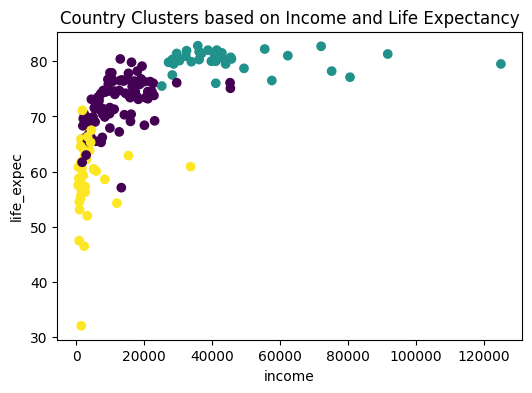

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(df['income'],df['life_expec'],c=df['cluster'],cmap='viridis')
plt.xlabel('income')
plt.ylabel('life_expec')
plt.title('Country Clusters based on Income and Life Expectancy')
plt.show()

***NOTE*** - **The scatter plot shows country clusters based on income and life expectancy. It highlights that high income and high life expectancy countries are developed, low income and low life expectancy countries are underdeveloped, and others fall into developing groups, clearly showing the separation of development levels.**

**Different colors represent different clusters:**

 purple (developing), green (developed), and yellow (underdeveloped) countries, showing clear separation based on income and life expectancy.**

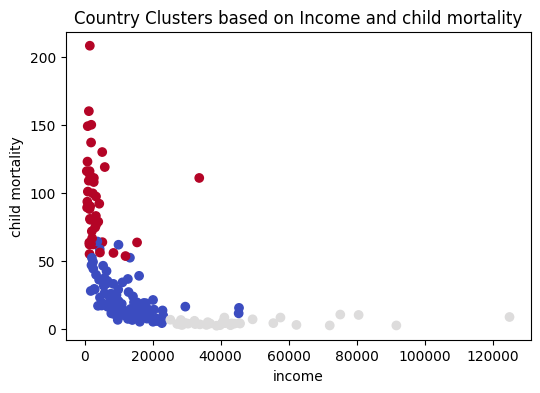

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(df['income'],df['child_mort'],c=df['cluster'],cmap='coolwarm')
plt.xlabel('income')
plt.ylabel('child mortality')
plt.title('Country Clusters based on Income and child mortality')
plt.show()

**The scatter plot shows country clusters based on income and child mortality. It clearly indicates that countries with low income and high child mortality belong to underdeveloped groups, while countries with higher income and lower child mortality belong to developing and developed groups.**

**Color Representation:**

Red - Underdeveloped countries (low income, high child mortality)

Purple - Developing countries

Blue - Developed countries (high income, low child mortality)

***Visualization techniques were used to represent the clustering results. Scatter plots were created using key development indicators such as income, life expectancy, and child mortality. These visualizations clearly showed how countries are grouped into clusters based on their socio-economic characteristics. Developed countries were characterized by high income, high GDP per capita, and high life expectancy, while underdeveloped countries showed low income and high child mortality. Visualization helps stakeholders such as NGOs and policymakers easily interpret the clustering results and identify countries that require development assistance***